### Data Preprocessing

In [ ]:
import pandas as pd
import numpy as np
df = pd.read_csv('earthquakes_data.csv')
df.head()

,Unnamed: 0,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,...,updated,place,type,horizontalError,depthError,magError,magNst,status,locationSource,magSource
0,0,1900-10-09T12:25:00.000Z,57.09,-153.48,NaN,7.86,mw,NaN,NaN,NaN,...,2022-05-09T14:44:17.838Z,"16 km SW of Old Harbor, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,pt
1,1,1901-03-03T07:45:00.000Z,36.00,-120.50,NaN,6.40,ms,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"12 km NNW of Parkfield, California",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,ell
2,2,1901-07-26T22:20:00.000Z,40.80,-115.70,NaN,5.00,fa,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"6 km SE of Elko, Nevada",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,sjg
3,3,1901-12-30T22:34:00.000Z,52.00,-160.00,NaN,7.00,ms,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,south of Alaska,earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,abe
4,4,1902-01-01T05:20:30.000Z,52.38,-167.45,NaN,7.00,ms,NaN,NaN,NaN,...,2018-06-04T20:43:44.000Z,"113 km ESE of Nikolski, Alaska",earthquake,NaN,NaN,NaN,NaN,reviewed,ushis,abe


In [ ]:
import os

# Replace this with the directory path you want to check
directory_path = '/content/drive/MyDrive/ImpactSense_Oct25/data/'

if os.path.exists(directory_path):
    print(f"Files in {directory_path}:")
    for filename in os.listdir(directory_path):
        print(filename)
else:
    print(f"Directory not found: {directory_path}")

Directory not found: /content/drive/MyDrive/ImpactSense_Oct25/data/


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110133 entries, 0 to 110132
Data columns (total 23 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   Unnamed: 0       110133 non-null  int64  
 1   time             110133 non-null  object 
 2   latitude         110133 non-null  float64
 3   longitude        110133 non-null  float64
 4   depth            109848 non-null  float64
 5   mag              110133 non-null  float64
 6   magType          110133 non-null  object 
 7   nst              39492 non-null   float64
 8   gap              49783 non-null   float64
 9   dmin             29839 non-null   float64
 10  rms              81386 non-null   float64
 11  net              110133 non-null  object 
 12  id               110133 non-null  object 
 13  updated          110133 non-null  object 
 14  place            109242 non-null  object 
 15  type             110133 non-null  object 
 16  horizontalError  28459 non-null   floa

In [ ]:
df.columns

Index(['Unnamed: 0', 'time', 'latitude', 'longitude', 'depth', 'mag',
       'magType', 'nst', 'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place',
       'type', 'horizontalError', 'depthError', 'magError', 'magNst', 'status',
       'locationSource', 'magSource'],
      dtype='object')

In [ ]:
df.isnull().sum()

Unnamed: 0             0
time                   0
latitude               0
longitude              0
depth                285
mag                    0
magType                0
nst                70641
gap                60350
dmin               80294
rms                28747
net                    0
id                     0
updated                0
place                891
type                   0
horizontalError    81674
depthError         49715
magError           67061
magNst             60025
status                 0
locationSource         0
magSource              0
dtype: int64

In [ ]:
df.shape

(110133, 23)

In [ ]:
round(df.isnull().sum()*100/df.shape[0],2)

Unnamed: 0          0.00
time                0.00
latitude            0.00
longitude           0.00
depth               0.26
mag                 0.00
magType             0.00
nst                64.14
gap                54.80
dmin               72.91
rms                26.10
net                 0.00
id                  0.00
updated             0.00
place               0.81
type                0.00
horizontalError    74.16
depthError         45.14
magError           60.89
magNst             54.50
status              0.00
locationSource      0.00
magSource           0.00
dtype: float64

In [ ]:
missing_percentage = round(df.isnull().sum()*100/df.shape[0],2)

threshold = 30
cols_to_drop = missing_percentage[missing_percentage > threshold].index.tolist()

df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

df.isnull().sum()

Unnamed: 0            0
time                  0
latitude              0
longitude             0
depth               285
mag                   0
magType               0
rms               28747
net                   0
id                    0
updated               0
place               891
type                  0
status                0
locationSource        0
magSource             0
dtype: int64

In [ ]:
df.columns

Index(['Unnamed: 0', 'time', 'latitude', 'longitude', 'depth', 'mag',
       'magType', 'rms', 'net', 'id', 'updated', 'place', 'type', 'status',
       'locationSource', 'magSource'],
      dtype='object')

In [ ]:
cols_to_drop = ['Unnamed: 0', 'id', 'net', 'locationSource', 'magSource','updated', 'place' ]
df.drop(columns=cols_to_drop, inplace=True, errors='ignore')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110133 entries, 0 to 110132
Data columns (total 9 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   time       110133 non-null  object 
 1   latitude   110133 non-null  float64
 2   longitude  110133 non-null  float64
 3   depth      109848 non-null  float64
 4   mag        110133 non-null  float64
 5   magType    110133 non-null  object 
 6   rms        81386 non-null   float64
 7   type       110133 non-null  object 
 8   status     110133 non-null  object 
dtypes: float64(5), object(4)
memory usage: 7.6+ MB


In [ ]:
df = df.dropna(subset=['depth'])

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# Select features that likely correlate with 'rms'
predictors = ['mag', 'depth', 'nst', 'gap', 'dmin']
available_features = [f for f in predictors if f in df.columns]

# Separate rows with known and unknown RMS values
df_known = df[df['rms'].notnull()]
df_unknown = df[df['rms'].isnull()]

# Keep only predictors that have minimal missingness
df_known = df_known.dropna(subset=available_features)
df_missing = df[df['rms'].isnull()]

if not df_known.empty and not df_missing.empty:
  X_train = df_known[available_features]
  y_train = df_known['rms']

  model = LinearRegression()
  model.fit(X_train, y_train)

  df.loc[df['rms'].isnull(), 'rms'] = model.predict(df_missing[available_features])

print(f"Missing RMS after regression imputation: {df['rms'].isnull().sum()}")


Missing RMS after regression imputation: 0


In [ ]:
# Check remaining missing values
round(df.isnull().sum()*100/df.shape[0],2)

time         0.0
latitude     0.0
longitude    0.0
depth        0.0
mag          0.0
magType      0.0
rms          0.0
type         0.0
status       0.0
dtype: float64

In [ ]:
# Convert "time" column to datetime
df['Datetime'] = pd.to_datetime(df['time'], errors='coerce')

# Extract temporal features
df['Year'] = df['Datetime'].dt.year
df['Month'] = df['Datetime'].dt.month
df['Day'] = df['Datetime'].dt.day
df['Hour']  = df['Datetime'].dt.hour
df['Minute'] = df['Datetime'].dt.minute
df['DayOfWeek'] = df['Datetime'].dt.dayofweek

df.head()

,time,latitude,longitude,depth,mag,magType,rms,type,status,Datetime,Year,Month,Day,Hour,Minute,DayOfWeek
16,1904-04-04T10:26:00.880Z,41.758,23.249,15.0,7.02,mw,1.032335,earthquake,reviewed,1904-04-04 10:26:00.880000+00:00,1904,4,4,10,26,0
17,1904-04-04T10:02:34.560Z,41.802,23.108,15.0,6.84,mw,1.023418,earthquake,reviewed,1904-04-04 10:02:34.560000+00:00,1904,4,4,10,2,0
18,1904-06-25T21:00:38.720Z,52.763,160.277,30.0,7.70,mw,1.065273,earthquake,reviewed,1904-06-25 21:00:38.720000+00:00,1904,6,25,21,0,5
19,1904-06-25T14:45:39.140Z,51.424,161.638,15.0,7.50,mw,1.056114,earthquake,reviewed,1904-06-25 14:45:39.140000+00:00,1904,6,25,14,45,5
20,1904-08-30T11:43:20.850Z,30.684,100.608,15.0,7.09,mw,1.035803,earthquake,reviewed,1904-08-30 11:43:20.850000+00:00,1904,8,30,11,43,1


In [ ]:
# Cyclical encoding for Month, Hour, DayOfWeek
df['Month_sin'] = np.sin(2 * np.pi * df['Month'] / 12)
df['Month_cos'] = np.cos(2 * np.pi * df['Month'] / 12)
df['Hour_sin'] = np.sin(2 * np.pi * df['Hour'] / 24)
df['Hour_cos'] = np.cos(2 * np.pi * df['Hour'] / 24)
df['DayOfWeek_sin'] = np.sin(2 * np.pi * df['DayOfWeek'] / 7)
df['DayOfWeek_cos'] = np.cos(2 * np.pi * df['DayOfWeek'] / 7)

In [ ]:
# Drop original 'time' and intermediate columns
df.drop(['time', 'Datetime', 'Month', 'Hour', 'DayOfWeek'], axis=1, inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109848 entries, 16 to 110132
Data columns (total 17 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   latitude       109848 non-null  float64
 1   longitude      109848 non-null  float64
 2   depth          109848 non-null  float64
 3   mag            109848 non-null  float64
 4   magType        109848 non-null  object 
 5   rms            109848 non-null  float64
 6   type           109848 non-null  object 
 7   status         109848 non-null  object 
 8   Year           109848 non-null  int32  
 9   Day            109848 non-null  int32  
 10  Minute         109848 non-null  int32  
 11  Month_sin      109848 non-null  float64
 12  Month_cos      109848 non-null  float64
 13  Hour_sin       109848 non-null  float64
 14  Hour_cos       109848 non-null  float64
 15  DayOfWeek_sin  109848 non-null  float64
 16  DayOfWeek_cos  109848 non-null  float64
dtypes: float64(11), int32(3), object(

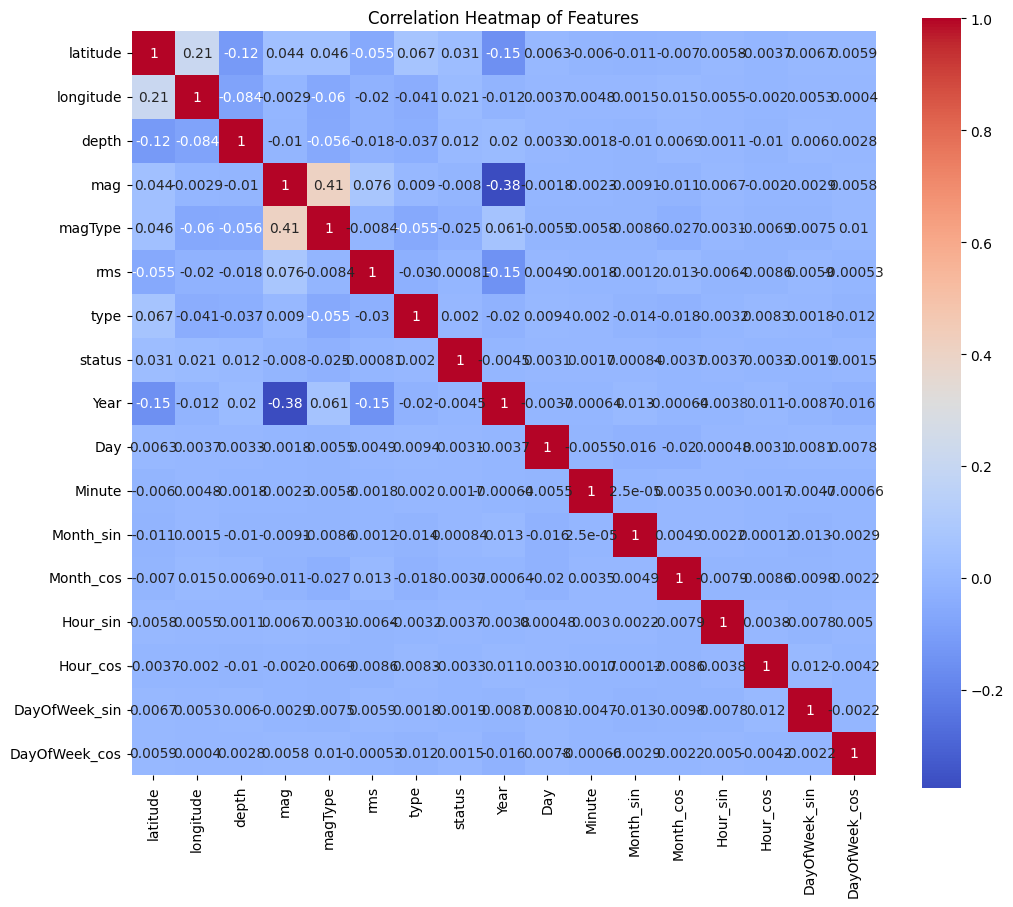

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = ['type', 'magType', 'status']

df_corr = df.copy()

for col in categorical_cols:
   df_corr[col] = df_corr[col].astype('category').cat.codes

corr_matrix = df_corr.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', cbar=True, square=True)
plt.title('Correlation Heatmap of Features')
plt.show()

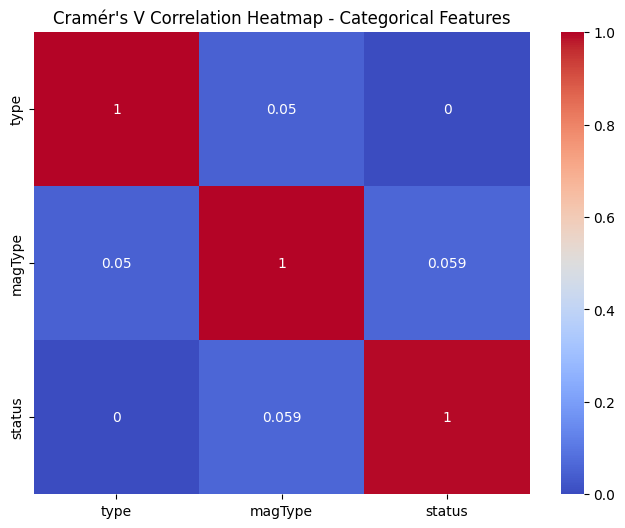

In [ ]:
# Function to compute Cramér's V correlation between two categorical variables

from scipy.stats import chi2_contingency

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    rcorr = r - ((r-1)**2) / (n-1)
    kcorr = k - ((k-1)**2) / (n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Updated list of categorical columns based on current DataFrame
categorical_cols = ['type', 'magType', 'status']

# Initialize empty DataFrame to store Cramér's V results
cramers_results = pd.DataFrame(np.zeros((len(categorical_cols), len(categorical_cols))),
                              index=categorical_cols, columns=categorical_cols)

# Calculate Cramér's V for each pair of categorical features
for col1 in categorical_cols:
    for col2 in categorical_cols:
        cramers_results.loc[col1, col2] = cramers_v(df[col1], df[col2])

# Plot heatmap of Cramér's V values
plt.figure(figsize=(8, 6))
sns.heatmap(cramers_results, annot=True, cmap='coolwarm', vmin=0, vmax=1)
plt.title("Cramér's V Correlation Heatmap - Categorical Features")
plt.show()

In [ ]:
df.head()

,latitude,longitude,depth,mag,magType,rms,type,status,Year,Day,Minute,Month_sin,Month_cos,Hour_sin,Hour_cos,DayOfWeek_sin,DayOfWeek_cos
16,41.758,23.249,15.0,7.02,mw,1.032335,earthquake,reviewed,1904,4,26,8.660254e-01,-0.5,0.500000,-0.866025,0.000000,1.000000
17,41.802,23.108,15.0,6.84,mw,1.023418,earthquake,reviewed,1904,4,2,8.660254e-01,-0.5,0.500000,-0.866025,0.000000,1.000000
18,52.763,160.277,30.0,7.70,mw,1.065273,earthquake,reviewed,1904,25,0,1.224647e-16,-1.0,-0.707107,0.707107,-0.974928,-0.222521
19,51.424,161.638,15.0,7.50,mw,1.056114,earthquake,reviewed,1904,25,45,1.224647e-16,-1.0,-0.500000,-0.866025,-0.974928,-0.222521
20,30.684,100.608,15.0,7.09,mw,1.035803,earthquake,reviewed,1904,30,43,-8.660254e-01,-0.5,0.258819,-0.965926,0.781831,0.623490


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# List numeric columns present in your DataFrame to scale/normalize
numeric_features = ['latitude', 'longitude', 'depth', 'mag', 'rms', 'year', 'day',
                    'month_sin', 'month_cos', 'hour_sin', 'hour_cos']

# Retain only features that actually exist in df for safety
numeric_features = [col for col in numeric_features if col in df.columns]

# Standard Scaling (z-score normalization)
scaler = StandardScaler()
df[numeric_features] = scaler.fit_transform(df[numeric_features])

# Alternatively, for Min-Max Normalization (uncomment below)
# normalizer = MinMaxScaler()
# df[numeric_features] = normalizer.fit_transform(df[numeric_features])

print(f"Scaled numeric features: {numeric_features}")


Scaled numeric features: ['latitude', 'longitude', 'depth', 'mag', 'rms']


In [ ]:
df.head()

,latitude,longitude,depth,mag,magType,rms,type,status,Year,Day,Minute,Month_sin,Month_cos,Hour_sin,Hour_cos,DayOfWeek_sin,DayOfWeek_cos
16,1.254896,-0.152401,-0.430517,3.296720,mw,0.255959,earthquake,reviewed,1904,4,26,8.660254e-01,-0.5,0.500000,-0.866025,0.000000,1.000000
17,1.256343,-0.153559,-0.430517,2.920854,mw,0.227615,earthquake,reviewed,1904,4,2,8.660254e-01,-0.5,0.500000,-0.866025,0.000000,1.000000
18,1.616780,0.972437,-0.291162,4.716657,mw,0.360656,earthquake,reviewed,1904,25,0,1.224647e-16,-1.0,-0.707107,0.707107,-0.974928,-0.222521
19,1.572749,0.983609,-0.430517,4.299028,mw,0.331543,earthquake,reviewed,1904,25,45,1.224647e-16,-1.0,-0.500000,-0.866025,-0.974928,-0.222521
20,0.890744,0.482625,-0.430517,3.442890,mw,0.266982,earthquake,reviewed,1904,30,43,-8.660254e-01,-0.5,0.258819,-0.965926,0.781831,0.623490


In [ ]:
# Save the preprocessed dataframe to a new CSV file
df.to_csv('preprocessed_earthquake_data.csv', index=False)

- ### Observations:

In [ ]:
| Column Name | Data Type | Missing % | Cleaning / Notes                                                       |
| ----------- | --------- | --------- | ---------------------------------------------------------------------- |
| time        | datetime  | 0%        | Converted to datetime                                                  |
| latitude    | float     | 0%        | No action needed                                                       |
| longitude   | float     | 0%        | No action needed                                                       |
| depth       | float     | 0%        | Missing values replaced with **median**; outliers removed via IQR      |
| mag         | float     | 0%        | Outliers removed via IQR                                               |
| magType     | category  | ~0%       | Missing replaced with **mode**; normalized lowercase & stripped spaces |
| nst         | float     | 0%        | Missing rows dropped for regression imputation                         |
| gap         | float     | 0%        | Missing rows dropped for regression imputation                         |
| dmin        | float     | 0%        | No action needed                                                       |
| rms         | float     | 0%        | Missing values imputed using **Linear Regression**                     |
| type        | category  | 0%        | Normalized lowercase & stripped spaces                                 |
| status      | category  | 0%        | Missing replaced with **mode**; normalized                             |


Dropped columns: 'Unnamed: 0', 'id', 'net', 'locationSource', 'magSource', 'updated', 'place', horizontalError, depthError, magError (either irrelevant or excessive missingness)


We used Cramer’s V because we wanted to check how strongly the categorical columns like magType, status, type, magSource, and locationSource are related to each other. Cramer’s V gives a number between 0 and 1 
that shows the strength of this relationship. StandardScaler and MinMaxScaler, on the other hand, 
are only used to scale or normalize numbers so that machine learning models work better. They cannot tell us anything about relationships between categories, 
so they are not useful here. That’s why Cramer’s V was the right choice for analyzing the categorical data